# This file plots the normalized hysteresis area for Omega Aragonite

author: Eike E. Köhn ......
date: Mar 23, 2026 ......
instructions: can be run with environment "conda env:pangeo-meso-2024.01.22" on spirit1

## Import packages

In [1]:
print('Loading packages...')
import sys
sys.path.append('../00_modules/.')
from import_packages import PackageGetter
globals().update(PackageGetter.import_standard_packages_for_analysis_and_plotting())
globals().update(PackageGetter.import_custom_packages())

Loading packages...


## Decide if figures are to be saved (and if so the directory)

In [2]:
savefigs = True
plot_dir = Plotter._get_plot_dir('review_round_1')

## Set the parameters for the analysis of the 1pctCO2-cdr run

In [3]:
print('Setting parameters...')
run_params = Params.standard_set_1pctCO2cdr()  #Params.test_set_1pctCO2cdr() #

Setting parameters...


## Choose the variable that is to be analyzed - and its temporal resolution

In [4]:
print('Choosing variable and temporal resolution....')
variable_to_analyze = 'omegaa'
depth_to_analyze = 'surface'
temporal_resolution = 'annual_means'

Choosing variable and temporal resolution....


## Get the model data for the variable of choice

In [5]:
print("Getting the variable's model dataset...")
run_paths = ModelDataGetter._identify_path_strings(run_params,variable_to_analyze,depth_to_analyze)

Getting the variable's model dataset...


## Get the additional ocean mask, area weights, atmospheric CO2, and ocean regions

In [6]:
print('Getting miscellaneous data...')
da_omask  = MiscDataGetter._get_ocean_mask()
da_area   = MiscDataGetter._get_grid_cell_areas()
ds_atmCO2 = MiscDataGetter._get_atmospheric_CO2(run_params)
ds_oregs, reg_lookup_dict  = MiscDataGetter._get_ocean_regions()

Getting miscellaneous data...
james' way to define atm. xco2, but taking into account that MIROC-ES2L and CanESM5 models branched at 139 and 141 years respectively (instead of 140).
james' way to define atm. xco2, but taking into account that MIROC-ES2L and CanESM5 models branched at 139 and 141 years respectively (instead of 140).
james' way to define atm. xco2, but taking into account that MIROC-ES2L and CanESM5 models branched at 139 and 141 years respectively (instead of 140).
james' way to define atm. xco2, but taking into account that MIROC-ES2L and CanESM5 models branched at 139 and 141 years respectively (instead of 140).
james' way to define atm. xco2, but taking into account that MIROC-ES2L and CanESM5 models branched at 139 and 141 years respectively (instead of 140).
james' way to define atm. xco2, but taking into account that MIROC-ES2L and CanESM5 models branched at 139 and 141 years respectively (instead of 140).
james' way to define atm. xco2, but taking into account th

## Compute the hysteresis area for the variable of choice - and compute the multimodel mean and agreements

In [7]:
hyst_dict = HystFuncs._calc_hysteresis_areas_3D_multimodel(run_params,run_paths,temporal_resolution,ds_atmCO2)

Calculating hysteresis area for model UKESM1-0-LL (key 2)...
Calculating hysteresis area for model NorESM2-LM (key 3)...
Calculating hysteresis area for model MIROC-ES2L (key 4)...
Calculating hysteresis area for model CNRM-ESM2-1 (key 5)...
Calculating hysteresis area for model ACCESS-ESM1-5 (key 6)...
Calculating hysteresis area for model CESM2 (key 7)...
Calculating hysteresis area for model CanESM5 (key 8)...
Calculating hysteresis area for model GFDL-ESM4 (key 9)...


In [8]:
print('Calculating multimodel mean and model agreement ...')
h_mmm,  h_agree  = MMFuncs._calc_multimodel_mean_and_agreement(hyst_dict, da_name='hysteresis_area',            agreement_type='mean_bigger_than_std')
hn_mmm, hn_agree = MMFuncs._calc_multimodel_mean_and_agreement(hyst_dict, da_name='normalized_hysteresis_area', agreement_type='mean_bigger_than_std')
hs_mmm, hs_agree = MMFuncs._calc_multimodel_mean_and_agreement(hyst_dict, da_name='signed_hysteresis_area', agreement_type='sign', agreement_thresh='at_least_80percent_agree')

Calculating multimodel mean and model agreement ...


## Pick example locations and regions for local analysis

In [9]:
set_of_loc_reg = MiscDataGetter._standard_set_of_regions_locations()
print('Chosen locations: ', set_of_loc_reg)

Chosen locations:  ['Global Ocean', [88, 260], [60, 90], 'central Arctic']


## Plot the multimodel mean normalized hysteresis area for the variable as a global map

Plot the multimodel mean hysteresis areas - globally....


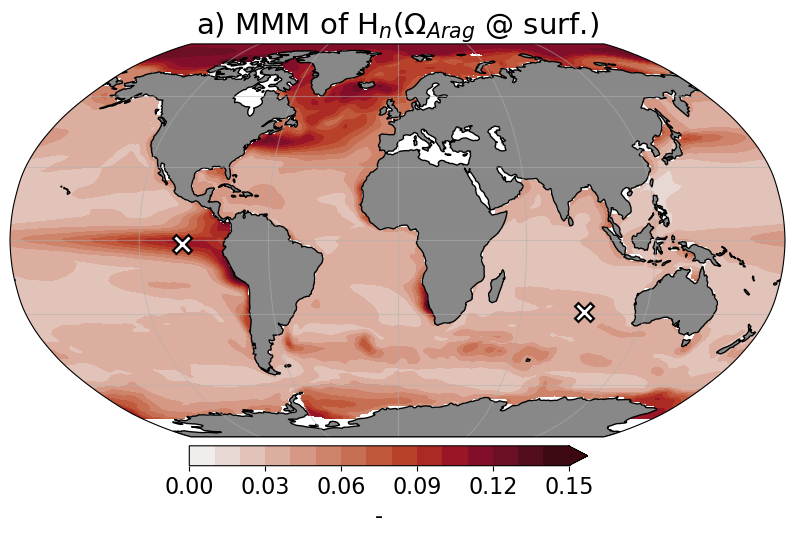

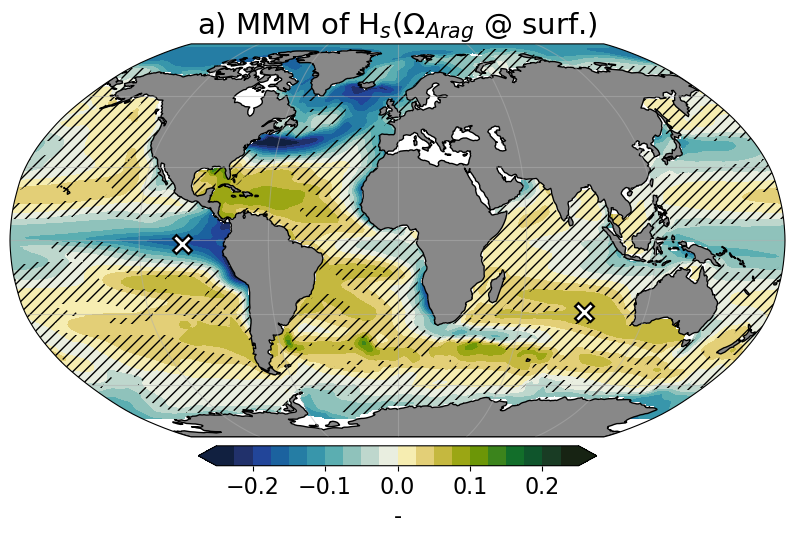

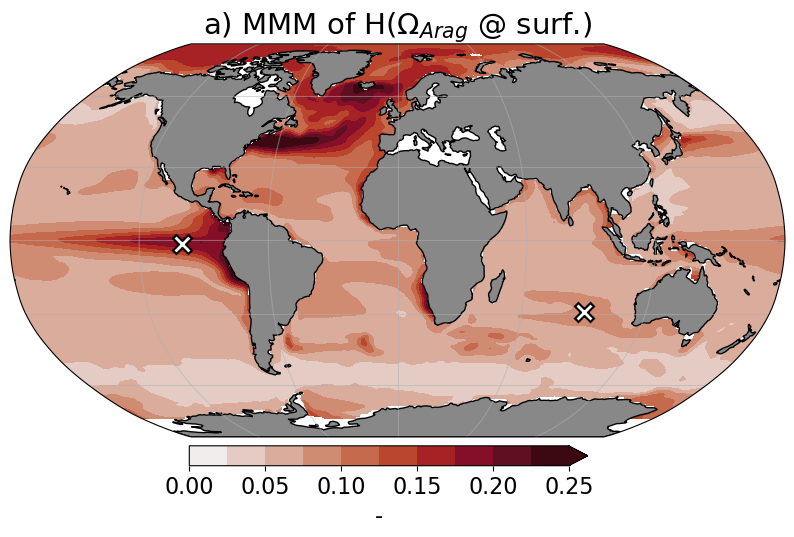

In [10]:
print('Plot the multimodel mean hysteresis areas - globally....')

fig, ax = Plotter.plot_global_map(hn_mmm,
                                  set_of_loc_reg,
                                  vmin=0,
                                  vmax=.15, #150,
                                  nlevs=16,
                                  cmap=plt.get_cmap('cmo.amp',15),
                                  cticks = [0,.030,.060,.090,.120,.150],
                                  extend='max',
                                  clabel='-',
                                  title=r'a) MMM of H$_n$($\Omega_{Arag}$ @ surf.)',
                                  agreement=None)
if savefigs == True:
    fig.savefig(f'{plot_dir}/map_global_hysteresis_normalized_mmm_{variable_to_analyze}.png',dpi=300,transparent=True)


fig, ax = Plotter.plot_global_map(hs_mmm,
                                  set_of_loc_reg,
                                  vmin=-.25,
                                  vmax=.25,
                                  nlevs=21,
                                  cticks = [-.2,-.1,0,.1,.2],#,30,60,90,120,150],
                                  cmap=plt.get_cmap('cmo.delta',20),
                                  extend='both',
                                  clabel='-',
                                  title=r'a) MMM of H$_s$($\Omega_{Arag}$ @ surf.)',
                                  agreement=hs_agree)
if savefigs == True:
    fig.savefig(f'{plot_dir}/map_global_hysteresis_signed_mmm_{variable_to_analyze}.png',dpi=300,transparent=True)


fig, ax = Plotter.plot_global_map(h_mmm,
                                  set_of_loc_reg,
                                  vmin=0,
                                  vmax=0.25,
                                  nlevs=11,
                                  cticks = [0,0.05,0.10,0.15,0.20,0.25],#,30,60,90,120,150],
                                  cmap=plt.get_cmap('cmo.amp',10),
                                  extend='max',
                                  clabel=r'-',
                                  title=r'a) MMM of H($\Omega_{Arag}$ @ surf.)',
                                  agreement=None)
if savefigs == True:
    fig.savefig(f'{plot_dir}/map_global_hysteresis_full_mmm_{variable_to_analyze}.png',dpi=300,transparent=True)



## Plot the multimodel mean normalized hysteresis area for the variable as an Arctic map

Plot the multimodel mean hysteresis areas - for the Arctic....


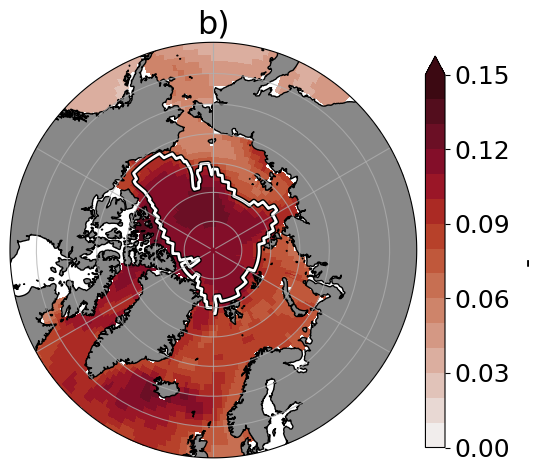

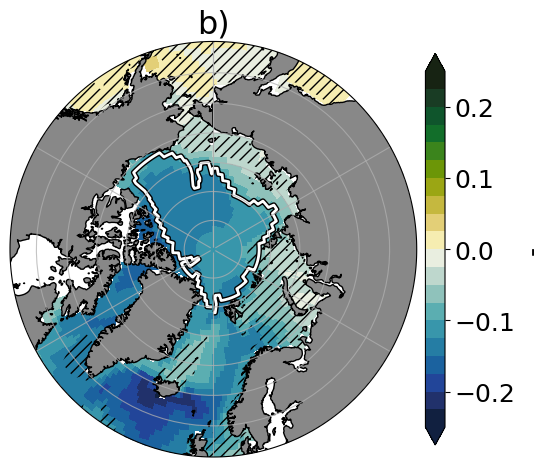

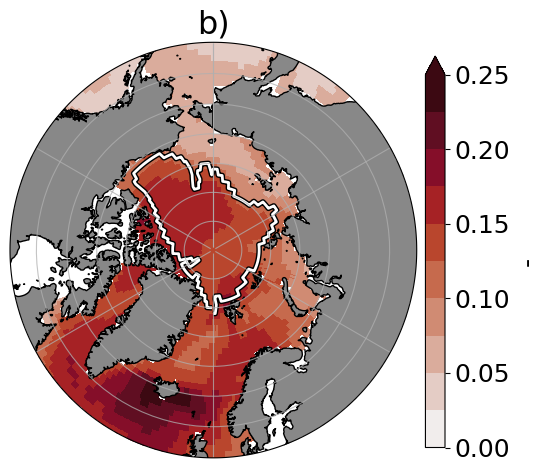

In [11]:
print('Plot the multimodel mean hysteresis areas - for the Arctic....')

fig, ax = Plotter.plot_arctic_map(hn_mmm,
                                  set_of_loc_reg,
                                  vmin=0,
                                  vmax=.15, #150,
                                  nlevs=16,
                                  cmap=plt.get_cmap('cmo.amp',15),
                                  cticks = [0,.030,.060,.090,.120,.150],
                                  extend='max',
                                  clabel='-',
                                  title=r'b)',
                                  agreement=None)
if savefigs == True:
    fig.savefig(f'{plot_dir}/map_arctic_hysteresis_normalized_mmm_{variable_to_analyze}.png',dpi=300,transparent=True)

fig, ax = Plotter.plot_arctic_map(hs_mmm,
                                  set_of_loc_reg,
                                  vmin=-.25,
                                  vmax=.25,
                                  nlevs=20,
                                  cticks = [-.2,-.1,0,.1,.2],#,30,60,90,120,150],
                                  cmap=plt.get_cmap('cmo.delta',20),
                                  extend='both',
                                  clabel='-',
                                  title=r'b)',
                                  agreement=hs_agree)
if savefigs == True:
    fig.savefig(f'{plot_dir}/map_arctic_hysteresis_signed_mmm_{variable_to_analyze}.png',dpi=300,transparent=True)

fig, ax = Plotter.plot_arctic_map(h_mmm,
                                  set_of_loc_reg,
                                  vmin=0,
                                  vmax=0.25,
                                  nlevs=11,
                                  cticks = [0,0.05,0.10,0.15,0.20,0.25],#,30,60,90,120,150],
                                  cmap=plt.get_cmap('cmo.amp',10),
                                  extend='max',
                                  clabel=r'-',
                                  title=r'b)',
                                  agreement=None)
if savefigs == True:
    fig.savefig(f'{plot_dir}/map_arctic_hysteresis_full_mmm_{variable_to_analyze}.png',dpi=300,transparent=True)


## Compute regional mean or extract point location time series of the variable of choice

In [12]:
print('Get time series....')
regional_time_series = MMFuncs._calc_regional_means(run_params,set_of_loc_reg,run_paths,temporal_resolution)

Get time series....


## Plot the timeseries (against atmospheric CO2) at the chosen locations

Plot the timeseries against atmospheric CO2 at four different locations....
UKESM1-0-LL
down  237 430.50313159395034
NorESM2-LM
down  260 342.29005881698185
MIROC-ES2L
down  258 342.9037651193848
CNRM-ESM2-1
down  240 419.35502946548485
ACCESS-ESM1-5
down  247 390.46897731863464
CESM2
down  264 329.8759002415229
CanESM5
down  248 395.4505164911025
GFDL-ESM4
down  236 435.1641828430687
Rampup crossing 1 at XX ppm: [488.2806824831727, 486.2260561210149, 508.3909628563447, 484.3502663293214, 485.4819811046493, 489.85663635647177, 508.3630733301089, 584.7605772056413]
MMM: 504.4637794733406+-31.72329758942414
Rampdown crossing 1 at XX ppm: [430.50313159395034, 342.29005881698185, 342.9037651193848, 419.35502946548485, 390.46897731863464, 329.8759002415229, 395.4505164911025, 435.1641828430687]
MMM: 385.75144523626636+-39.586538690892986
Difference:
MMM: -118.71233423707429+-39.80404698471118
Start-end difference:
MMM: 0.3781707470406186+-0.10668777281054688


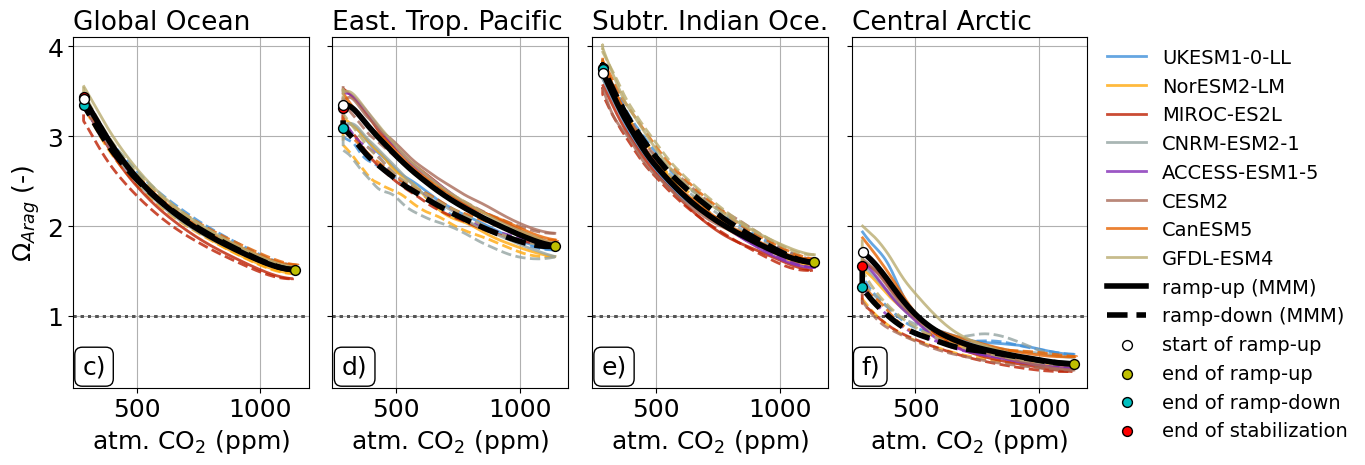

In [13]:
# Define some helper functions
def find_and_print_the_ppm_value_at_which_omega_crosses_1(ts, atm_co2):
    target = 1

    ts = ts.values
    #print(ts.size)
    atm_co2 = atm_co2.values

    def one_crossing(x, y):
        sign = np.sign(x - target)
        sign[sign == 0] = 1  # avoid zero ambiguity
        
        crossings = np.where(np.diff(sign) != 0)[0]
        
        if len(crossings) == 0:
            return None, None

        i = crossings[0] 
        
        x0, x1 = x[i], x[i+1]
        y0, y1 = y[i], y[i+1]
        
        frac = (target - x0) / (x1 - x0)
        y_interp = y0 + frac * (y1 - y0)
        
        return i, y_interp

    # ramp-up
    up_index, rampup_val = one_crossing(ts[:140], atm_co2[:140])

    # ramp-down
    dn_index, rampdn_val = one_crossing(ts[140:280], atm_co2[140:280])
    
    if dn_index is not None:
        dn_index += 140

    print('down ',dn_index, rampdn_val)
    
    return up_index, rampup_val, dn_index, rampdn_val

def find_and_print_start_end_difference(ts):
    ts = ts.values

    start_val = ts[0]
    end_val = ts[280]
    diff_val = start_val - end_val

    return start_val,end_val,diff_val


def plot_four_timeseries_against_atmCO2(run_params,regional_time_series,ds_atmCO2,set_of_loc_reg):

    panel_labels = ['c','d','e','f']
    up_index_all = []
    dn_index_all = []
    rampup_val_all = []
    rampdn_val_all = []
    
    start_val_all = []
    end_val_all = []
    diff_val_all = []

    fontsize=18
    fig, ax = plt.subplots(1,len(set_of_loc_reg),figsize=(14,5),sharey=True)

    # loop over regions
    for idx,loc_or_reg in enumerate(set_of_loc_reg):
        # loop over runs
        data_to_plot_all = [] 
        for key in run_params.keys():
            
            # Get the CO2 
            atmCO2 = ds_atmCO2[key]
            rampup_atmCO2   = atmCO2.isel(year=slice(0,  140))
            rampdown_atmCO2 = atmCO2.isel(year=slice(140,340))

            # Get the data
            # First, get the right region string
            if isinstance(loc_or_reg,str):
                loc_or_reg_string = loc_or_reg
            elif isinstance(loc_or_reg,list):
                loc_or_reg_string = f'point_{loc_or_reg[0]}_{loc_or_reg[1]}'
            else:
                raise Exception('Not yet implemented')
            
            # Now get the data and smooth it for better readability
            reg_time_series = regional_time_series[loc_or_reg_string][key]
            reg_time_series_smooth = Spliner.fspline1D(reg_time_series,0.06)
            reg_time_series_smooth_da = xr.DataArray(data = reg_time_series_smooth, coords = reg_time_series.coords, dims = reg_time_series.dims)
            data_to_plot_all.append(reg_time_series)

            rampup_timeseries   = reg_time_series_smooth_da.isel(year=slice(0,  140))
            rampdown_timeseries = reg_time_series_smooth_da.isel(year=slice(140,340))

            # Plot the rampup
            ax[idx].plot(rampup_atmCO2,   rampup_timeseries,   color=run_params[key].runcol, zorder=4, linewidth=2, label=run_params[key].model, alpha=.8)
            # Plot the rampdown
            ax[idx].plot(rampdown_atmCO2, rampdown_timeseries, color=run_params[key].runcol, zorder=4, linewidth=2, linestyle='--',alpha=.8)

            if loc_or_reg_string == 'central Arctic':
                # diagnose the saturation/undersaturation levels
                print(run_params[key].model)
                up_index,rampup_val,dn_index,rampdn_val = find_and_print_the_ppm_value_at_which_omega_crosses_1(reg_time_series,atmCO2)
                up_index_all.append(up_index)
                dn_index_all.append(dn_index)
                rampup_val_all.append(rampup_val)
                rampdn_val_all.append(rampdn_val)
                # diagnose the difference in start and end values
                start_val,end_val,diff_val = find_and_print_start_end_difference(reg_time_series)
                start_val_all.append(start_val)
                end_val_all.append(end_val)
                diff_val_all.append(diff_val)


        mmm = xr.concat(data_to_plot_all,dim='keys').mean(dim='keys')#.mean(data_to_plot_all,axis=0)
        mmm_smooth = Spliner.fspline1D(mmm,0.06)
        mmm_smooth_da = xr.DataArray(data = mmm_smooth, coords = mmm.coords, dims = mmm.dims)


        mmm_rampup = mmm_smooth_da.isel(year=slice(0,  140))
        mmm_rampdown = mmm_smooth_da.isel(year=slice(140,340))

        # Plot the MMM rampup
        ax[idx].plot(rampup_atmCO2,   mmm_rampup, color='k',zorder=4,linewidth=4,label='ramp-up (MMM)',alpha=1)
        # Plot the MMM rampdown
        ax[idx].plot(rampdown_atmCO2, mmm_rampdown, color='k',zorder=4,linestyle='--',label='ramp-down (MMM)',linewidth=4,alpha=1)

        # Scatter points at imprtant times
        ax[idx].scatter(atmCO2.isel(year=0),  mmm_smooth_da.isel(year=0),  50,facecolor='w',edgecolor='k',marker='o',zorder=6,label='start of ramp-up')
        ax[idx].scatter(atmCO2.isel(year=140),mmm_smooth_da.isel(year=140),50,facecolor='y',edgecolor='k',marker='o',zorder=5,label='end of ramp-up')
        ax[idx].scatter(atmCO2.isel(year=280),mmm_smooth_da.isel(year=280),50,facecolor='c',edgecolor='k',marker='o',zorder=5,label='end of ramp-down')
        ax[idx].scatter(atmCO2.isel(year=339),mmm_smooth_da.isel(year=339),50,facecolor='r',edgecolor='k',marker='o',zorder=4,label='end of stabilization')
    
        ax[idx].grid()
        ax[idx].set_xlabel('atm. CO$_2$ (ppm)')
        ax[idx].text(0.04,0.04,panel_labels[idx]+')',transform=ax[idx].transAxes,bbox={'boxstyle':'round','fc':'w'})#indices_titles[idx],loc='left')
        plt.subplots_adjust(wspace=0.03)
        ax[0].set_ylabel(r'$\Omega_{Arag}$ (-)')
        if loc_or_reg_string == 'central Arctic':
            ax[idx].legend(fontsize=fontsize-4,loc='lower left',bbox_to_anchor=(1.01,-0.2),edgecolor='w')
        
        if loc_or_reg_string == 'point_88_260':
            title_string ='East. Trop. Pacific'
        elif loc_or_reg_string == 'point_60_90':
            title_string = 'Subtr. Indian Oce.'
        elif loc_or_reg_string == 'central Arctic':
            title_string = 'Central Arctic'
        else:
            title_string = loc_or_reg_string

        ax[idx].set_title(title_string,loc='left',fontsize=fontsize+1)
    
        for axi in ax:
            axi.axhline(1,linestyle=':',color='#555555',linewidth=2)
            axi.set_ylim([0.2,4.1])
        plt.tight_layout()
        plt.subplots_adjust(wspace=0.1)
        
    return fig, ax, rampup_val_all, rampdn_val_all,start_val_all,end_val_all,diff_val_all


print('Plot the timeseries against atmospheric CO2 at four different locations....')
fig, ax, rampup_val_all, rampdn_val_all,start_val_all,end_val_all,diff_val_all = plot_four_timeseries_against_atmCO2(run_params,regional_time_series,ds_atmCO2,set_of_loc_reg)
print('Rampup crossing 1 at XX ppm:', rampup_val_all)
print(f'MMM: {np.mean(rampup_val_all)}+-{np.std(rampup_val_all)}')
print('Rampdown crossing 1 at XX ppm:', rampdn_val_all)
print(f'MMM: {np.mean(rampdn_val_all)}+-{np.std(rampdn_val_all)}')
print('Difference:')
print(f'MMM: {np.mean(np.array(rampdn_val_all)-np.array(rampup_val_all))}+-{np.std(np.array(rampdn_val_all)-np.array(rampup_val_all))}')
print('Start-end difference:')
print(f'MMM: {np.mean(diff_val_all)}+-{np.std(diff_val_all)}')
if savefigs == True:
    fig.savefig(f'{plot_dir}/time_series_against_co2_4regions_{variable_to_analyze}.png',dpi=300,transparent=True)


## Compute regional mean hysteresis areas of the variable of choice

In [14]:
print('Compute the regional hysteresis areas....')
regional_mean_normalized_hysteresis_areas = MMFuncs._calc_regional_means(run_params,set_of_loc_reg, hyst_dict, 'normalized_hysteresis_area')
regional_mean_signed_hysteresis_areas = MMFuncs._calc_regional_means(run_params,set_of_loc_reg, hyst_dict, 'signed_hysteresis_area')

Compute the regional hysteresis areas....


In [15]:
all_central = []
all_global = []
for key in ['2','3','4','5','6','7','8','9']:
    all_central.append(regional_mean_normalized_hysteresis_areas['central Arctic'][key].values)
    all_global.append(regional_mean_normalized_hysteresis_areas['Global Ocean'][key].values)
print('Central Arctic average of normalized hysteresis area:')
print(f'{np.mean(all_central)} +- {np.std(all_central)}')
print('Global Ocean average of normalized hysteresis area:')
print(f'{np.mean(all_global)} +- {np.std(all_global)}')

Central Arctic average of normalized hysteresis area:
0.11291962047358334 +- 0.021643778311745673
Global Ocean average of normalized hysteresis area:
0.039832958940060836 +- 0.006802693007101072


## Save the central Arctic hysteresis areas

In [16]:
region_to_save = 'central Arctic'
ds_hn = regional_mean_normalized_hysteresis_areas[region_to_save]
ds_hs = regional_mean_signed_hysteresis_areas[region_to_save]
              
ds_hn.attrs['unit'] = 'ppm'
ds_hn.attrs['name'] = 'normalized hysteresis area'
ds_hn.attrs['region'] = f'{region_to_save}'

ds_hs.attrs['unit'] = '-'
ds_hs.attrs['name'] = 'signed hysteresis area'
ds_hs.attrs['region'] = f'{region_to_save}'

############### SAVE THE AMOC hysteresis areas #################
ds_hn.to_netcdf(f'../07_plots_datasets_for_review_round1/fig01_{variable_to_analyze}_{region_to_save}_normalized_hysteresis_area.nc')
ds_hs.to_netcdf(f'../07_plots_datasets_for_review_round1/fig01_{variable_to_analyze}_{region_to_save}_signed_hysteresis_area.nc')

## Save the global hysteresis area maps

In [17]:
hyst_types = ['hysteresis_area','signed_hysteresis_area','normalized_hysteresis_area']
run_names = list(run_params.keys())  # or hyst_dict.keys()
hyst_ds = xr.Dataset()

for hyst_type in hyst_types:
    data_list = [hyst_dict[run][hyst_type] for run in run_names]

    # Ensure the data has a consistent dimension name (e.g., "run")
    hyst_da = xr.concat(data_list, dim='run')
    hyst_da = hyst_da.assign_coords(run=("run", run_names))

    # Add to dataset
    hyst_ds[hyst_type] = hyst_da

hyst_ds.to_netcdf(f'../07_plots_datasets_for_review_round1/fig05_{variable_to_analyze}_hysteresis_area_global_map.nc')

# Some supplementary plots

## First, calculate time series for chosen regions

In [18]:
set_of_loc_reg_2 = ['Global Ocean','Arctic Ocean','Barents Sea','central Arctic']
print('Chosen locations: ', set_of_loc_reg_2)
regional_time_series_2 = MMFuncs._calc_regional_means(run_params,set_of_loc_reg_2,run_paths,temporal_resolution)

Chosen locations:  ['Global Ocean', 'Arctic Ocean', 'Barents Sea', 'central Arctic']


## Plot the central Arctic time series, fancy

Plot the regional time series, but in fancy....
james' way to define atm. xco2, but taking into account that MIROC-ES2L and CanESM5 models branched at 139 and 141 years respectively (instead of 140).
james' way to define atm. xco2, but taking into account that MIROC-ES2L and CanESM5 models branched at 139 and 141 years respectively (instead of 140).
james' way to define atm. xco2, but taking into account that MIROC-ES2L and CanESM5 models branched at 139 and 141 years respectively (instead of 140).
james' way to define atm. xco2, but taking into account that MIROC-ES2L and CanESM5 models branched at 139 and 141 years respectively (instead of 140).
james' way to define atm. xco2, but taking into account that MIROC-ES2L and CanESM5 models branched at 139 and 141 years respectively (instead of 140).
james' way to define atm. xco2, but taking into account that MIROC-ES2L and CanESM5 models branched at 139 and 141 years respectively (instead of 140).
james' way to define atm. xco2, but taki

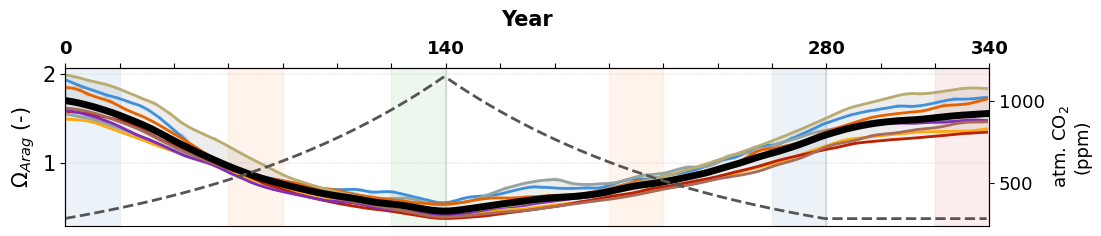

In [19]:
print('Plot the regional time series, but in fancy....')
fig, ax, ax2 = Plotter._plot_regional_time_series_fancy(run_params,regional_time_series_2,'central Arctic',variable_to_analyze,'$\Omega_{Arag}$ (-)',include_atmCO2=True)
if savefigs == True:
    fig.savefig(f'{plot_dir}/time_series_against_co2_1region_fancy_{variable_to_analyze}.png',dpi=300,transparent=True)


## Now plot the time slice averages, including for the piControl

Setting parameters...
Opening the variable's model dataset...
Compute time slice averages.....
Now plot the time slice....


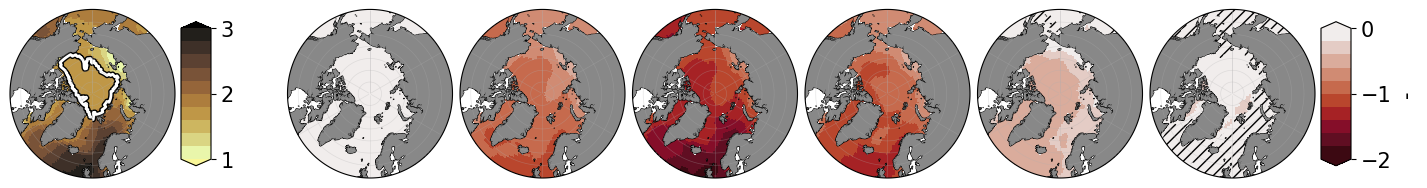

In [20]:
print('Setting parameters...')
pic_params = Params.standard_set_piControl() #Params.test_set_1pctCO2cdr()  #

print("Opening the variable's model dataset...")
pic_paths = ModelDataGetter._identify_path_strings(pic_params,variable_to_analyze,depth_to_analyze)
pic_data   = ModelDataGetter._open_datasets(pic_paths)

print('Compute time slice averages.....')
time_slices='standard'
time_slice_type='anom_to_preindustrial_initial'
time_slice_averages_mmm, time_slice_averages_agreement = MMFuncs._calc_time_slice_averages(run_paths,pic_paths,temporal_resolution,time_slices=time_slices,time_slice_type=time_slice_type)

print('Now plot the time slice....')
# set colormaps and units
cmap = plt.get_cmap('cmo.turbid',10);cmap.set_under('#faf798');cmap.set_over('k')
amap = plt.get_cmap('cmo.amp_r',10);#amap.set_under('m')
fig, ax = Plotter._plot_time_slice_averages(time_slice_averages_mmm,time_slice_averages_agreement,time_slice_type='anom_to_preindustrial_initial',
                                   vmin=1,vmax=3,
                                   cmap=cmap,
                                   amin=-2,amax=0,
                                   amap=amap,
                                   unit=r'-',
                                   include_region_mask='central Arctic')

if savefigs == True:
    fig.savefig(f'{plot_dir}/map_arctic_time_slice_averages_mmm_{variable_to_analyze}.png',dpi=300,transparent=True)

## Now plot the normalized hysteresis areas, but for each model separately

Plot the hysteresis areas for the individual models.....


/home/ekoehn/jobs/jupyter/arctic_acidification_reversibility/03_analysis_and_plotting/../00_modules/./funcs_for_plotting.py:326: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


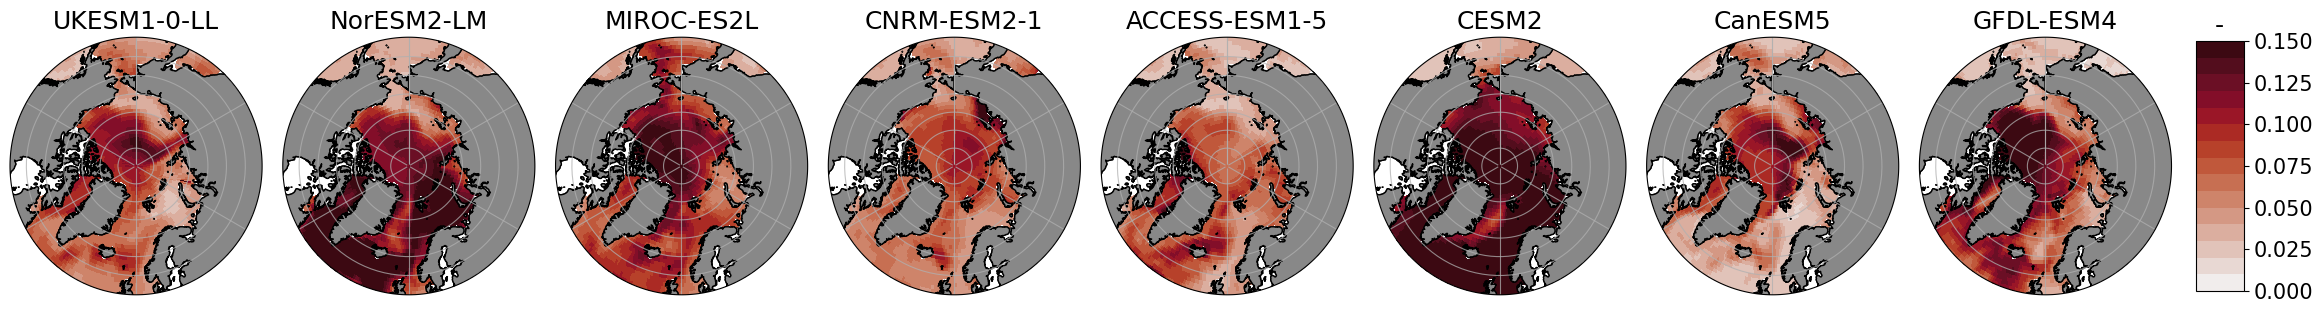

/home/ekoehn/jobs/jupyter/arctic_acidification_reversibility/03_analysis_and_plotting/../00_modules/./funcs_for_plotting.py:326: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


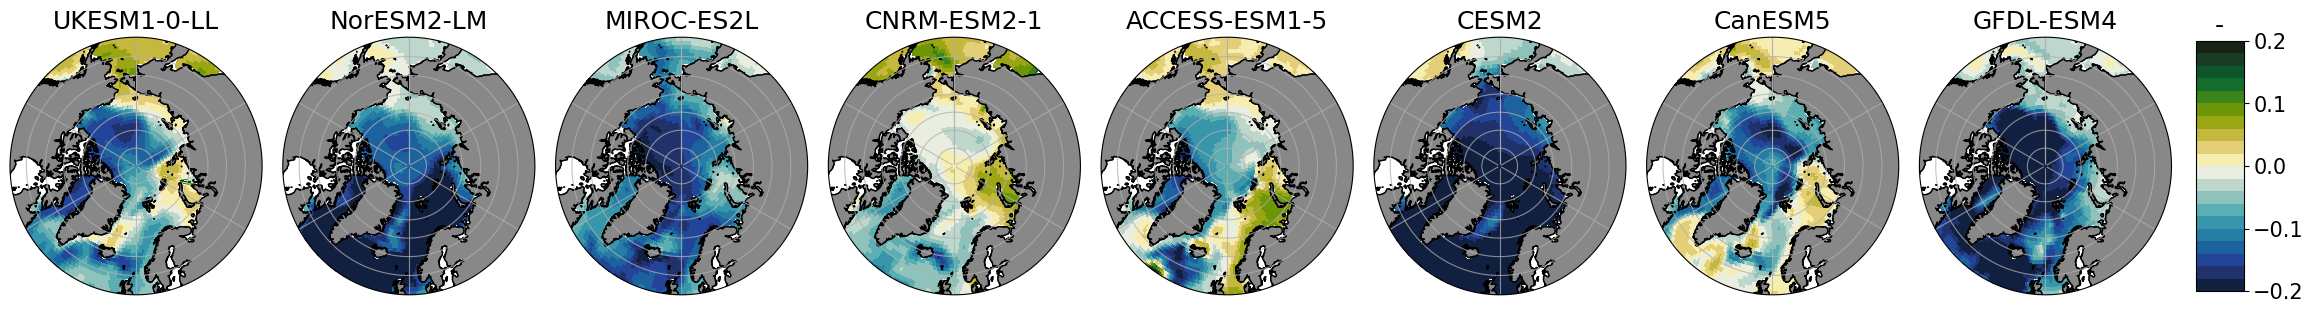

In [21]:
print('Plot the hysteresis areas for the individual models.....')
fig, ax = Plotter._plot_variable_for_individual_models(run_params,hyst_dict,da_name='normalized_hysteresis_area',vmin=0,vmax=0.15,cmap=plt.get_cmap('cmo.amp',15),unit='-')
if savefigs == True:
    fig.savefig(f'{plot_dir}/map_arctic_hysteresis_normalized_individual_models_{variable_to_analyze}.png',dpi=300,transparent=True)
    
fig, ax = Plotter._plot_variable_for_individual_models(run_params,hyst_dict,da_name='signed_hysteresis_area',vmin=-.2,vmax=.2,cmap=plt.get_cmap('cmo.delta',20),unit='-')
if savefigs == True:
    fig.savefig(f'{plot_dir}/map_arctic_hysteresis_signed_individual_models_{variable_to_analyze}.png',dpi=300,transparent=True)

Plot the hysteresis areas for the individual models.....


/home/ekoehn/jobs/jupyter/arctic_acidification_reversibility/03_analysis_and_plotting/../00_modules/./funcs_for_plotting.py:360: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


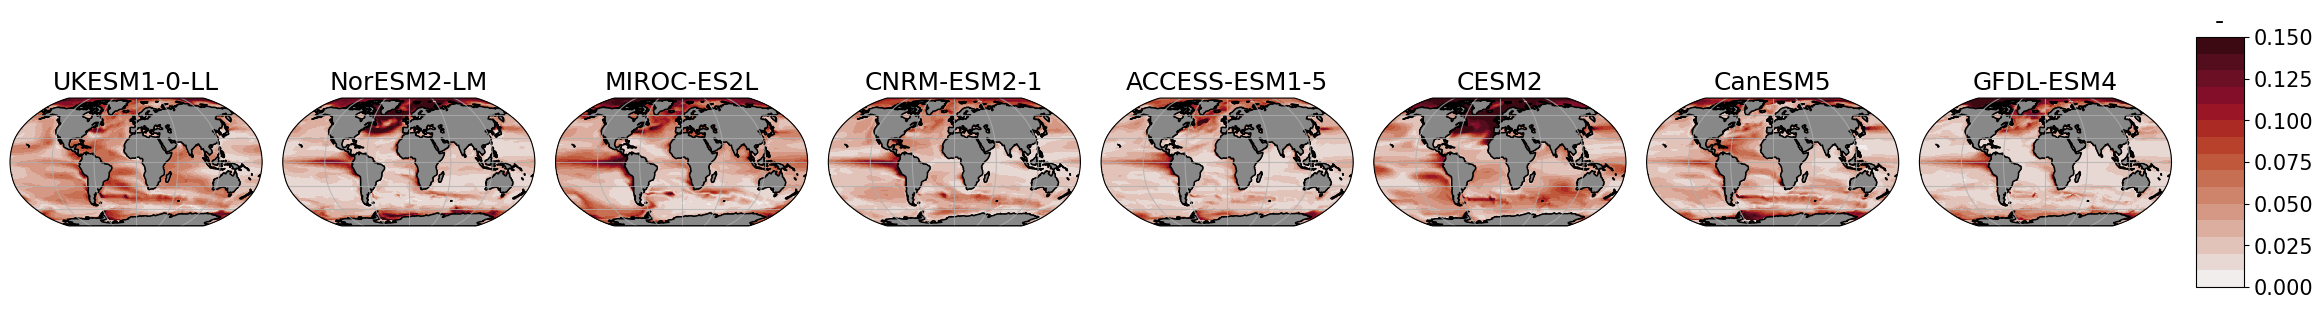

/home/ekoehn/jobs/jupyter/arctic_acidification_reversibility/03_analysis_and_plotting/../00_modules/./funcs_for_plotting.py:360: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


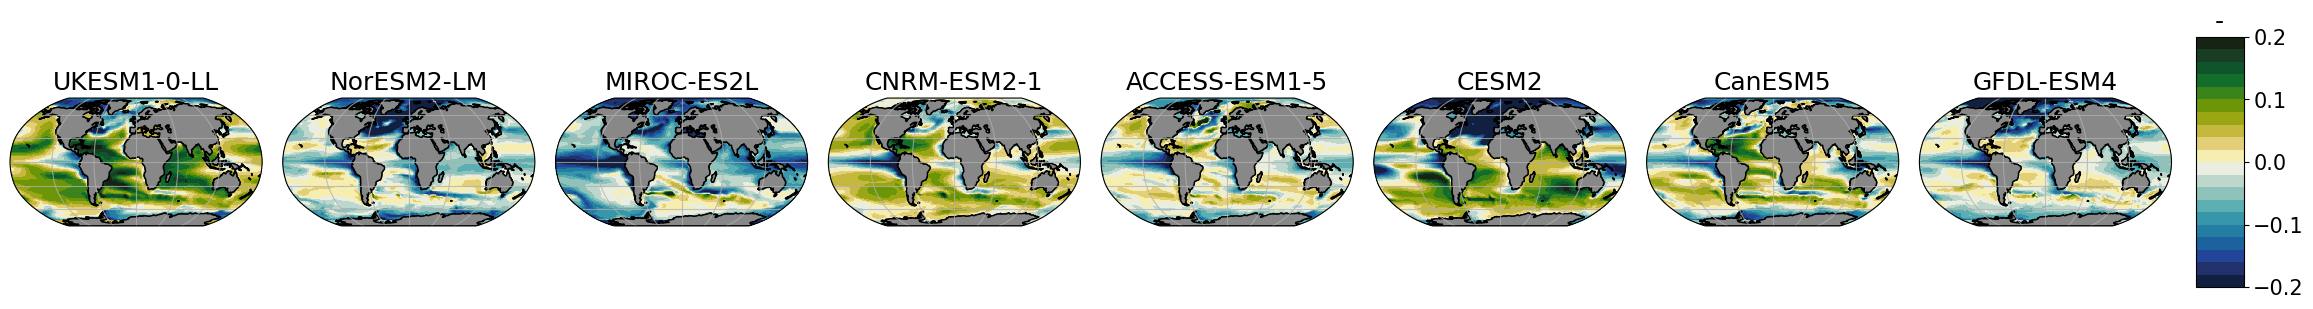

In [22]:
print('Plot the hysteresis areas for the individual models.....')
fig, ax = Plotter._plot_variable_for_individual_models_global(run_params,hyst_dict,da_name='normalized_hysteresis_area',vmin=0,vmax=0.15,cmap=plt.get_cmap('cmo.amp',15),unit='-')
if savefigs == True:
    fig.savefig(f'{plot_dir}/map_global_hysteresis_normalized_individual_models_{variable_to_analyze}.png',dpi=300,transparent=True)
    
fig, ax = Plotter._plot_variable_for_individual_models_global(run_params,hyst_dict,da_name='signed_hysteresis_area',vmin=-.2,vmax=.2,cmap=plt.get_cmap('cmo.delta',20),unit='-')
if savefigs == True:
    fig.savefig(f'{plot_dir}/map_global_hysteresis_signed_individual_models_{variable_to_analyze}.png',dpi=300,transparent=True)

Plot the hysteresis areas for the individual models (Global and Arctic together).....


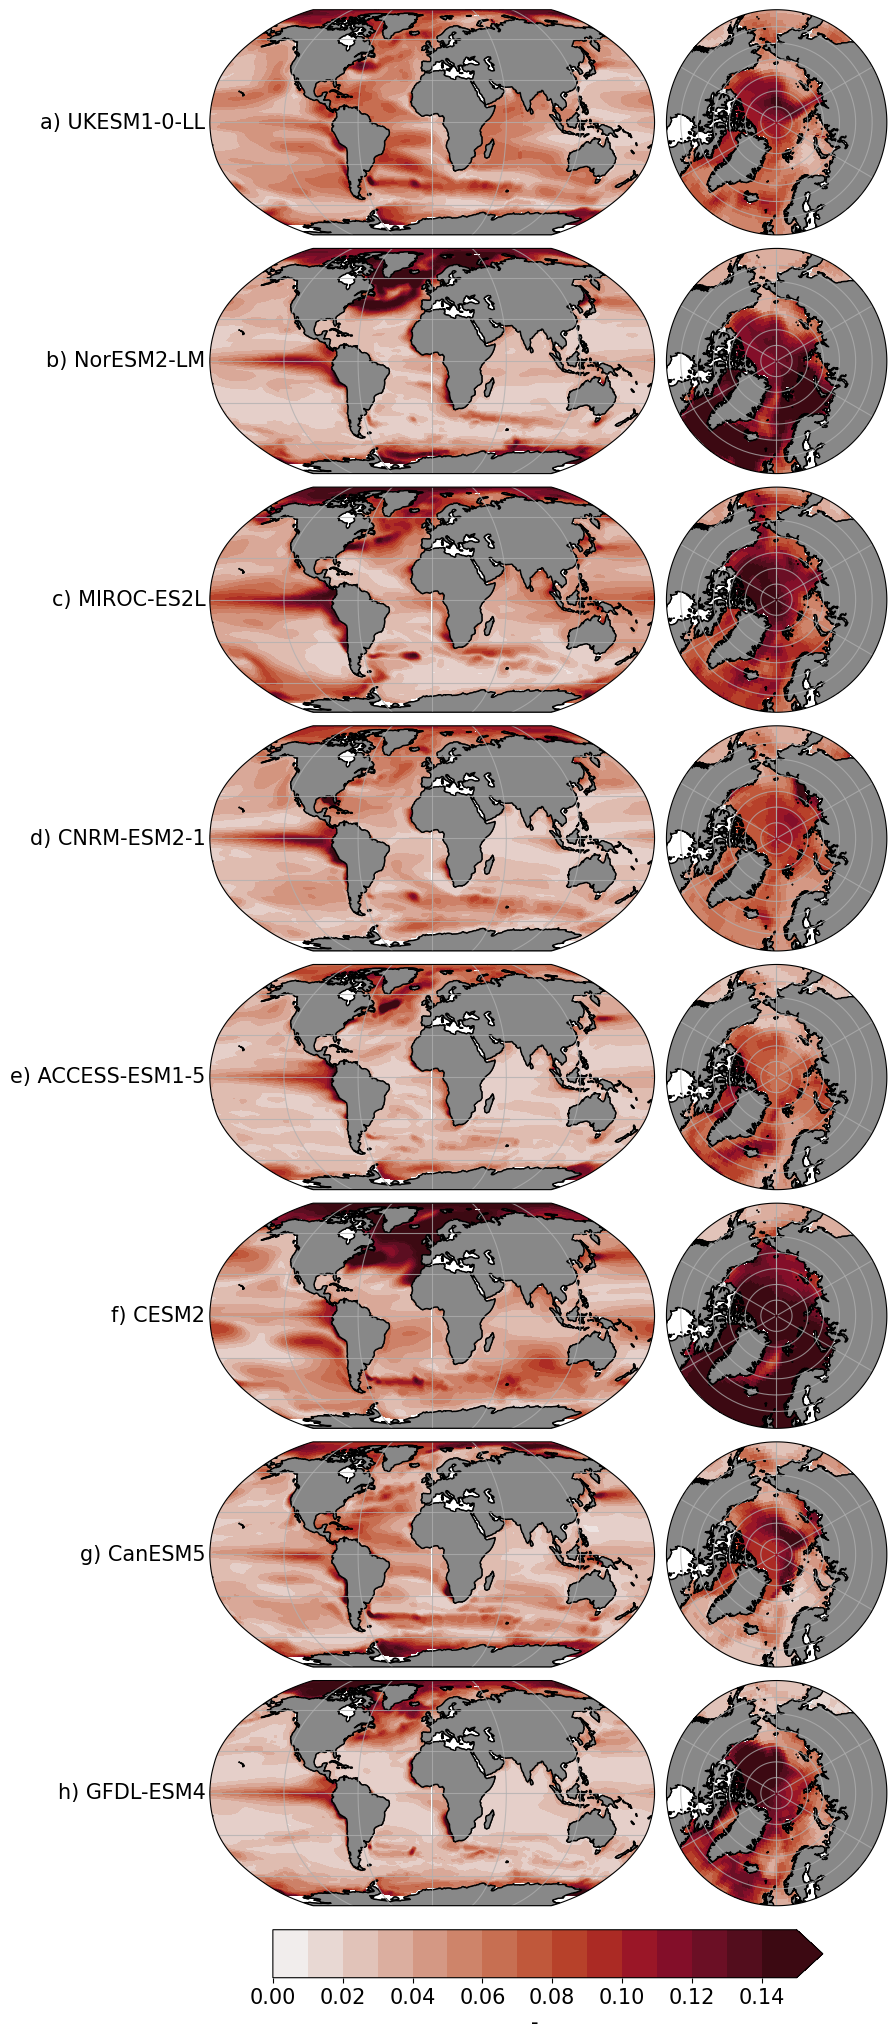

In [23]:
print('Plot the hysteresis areas for the individual models (Global and Arctic together).....')

fig = Plotter._plot_variable_for_individual_models_global_and_arctic(run_params,hyst_dict,da_name='normalized_hysteresis_area',vmin=0,vmax=0.15,cmap=plt.get_cmap('cmo.amp',15),unit='-',col=1)
if savefigs == True:
    fig.savefig(f'{plot_dir}/map_global_and_arctic_hysteresis_normalized_individual_models_{variable_to_analyze}.png',dpi=300,transparent=True)

Plot the hysteresis areas for the individual models (Global and Arctic together).....


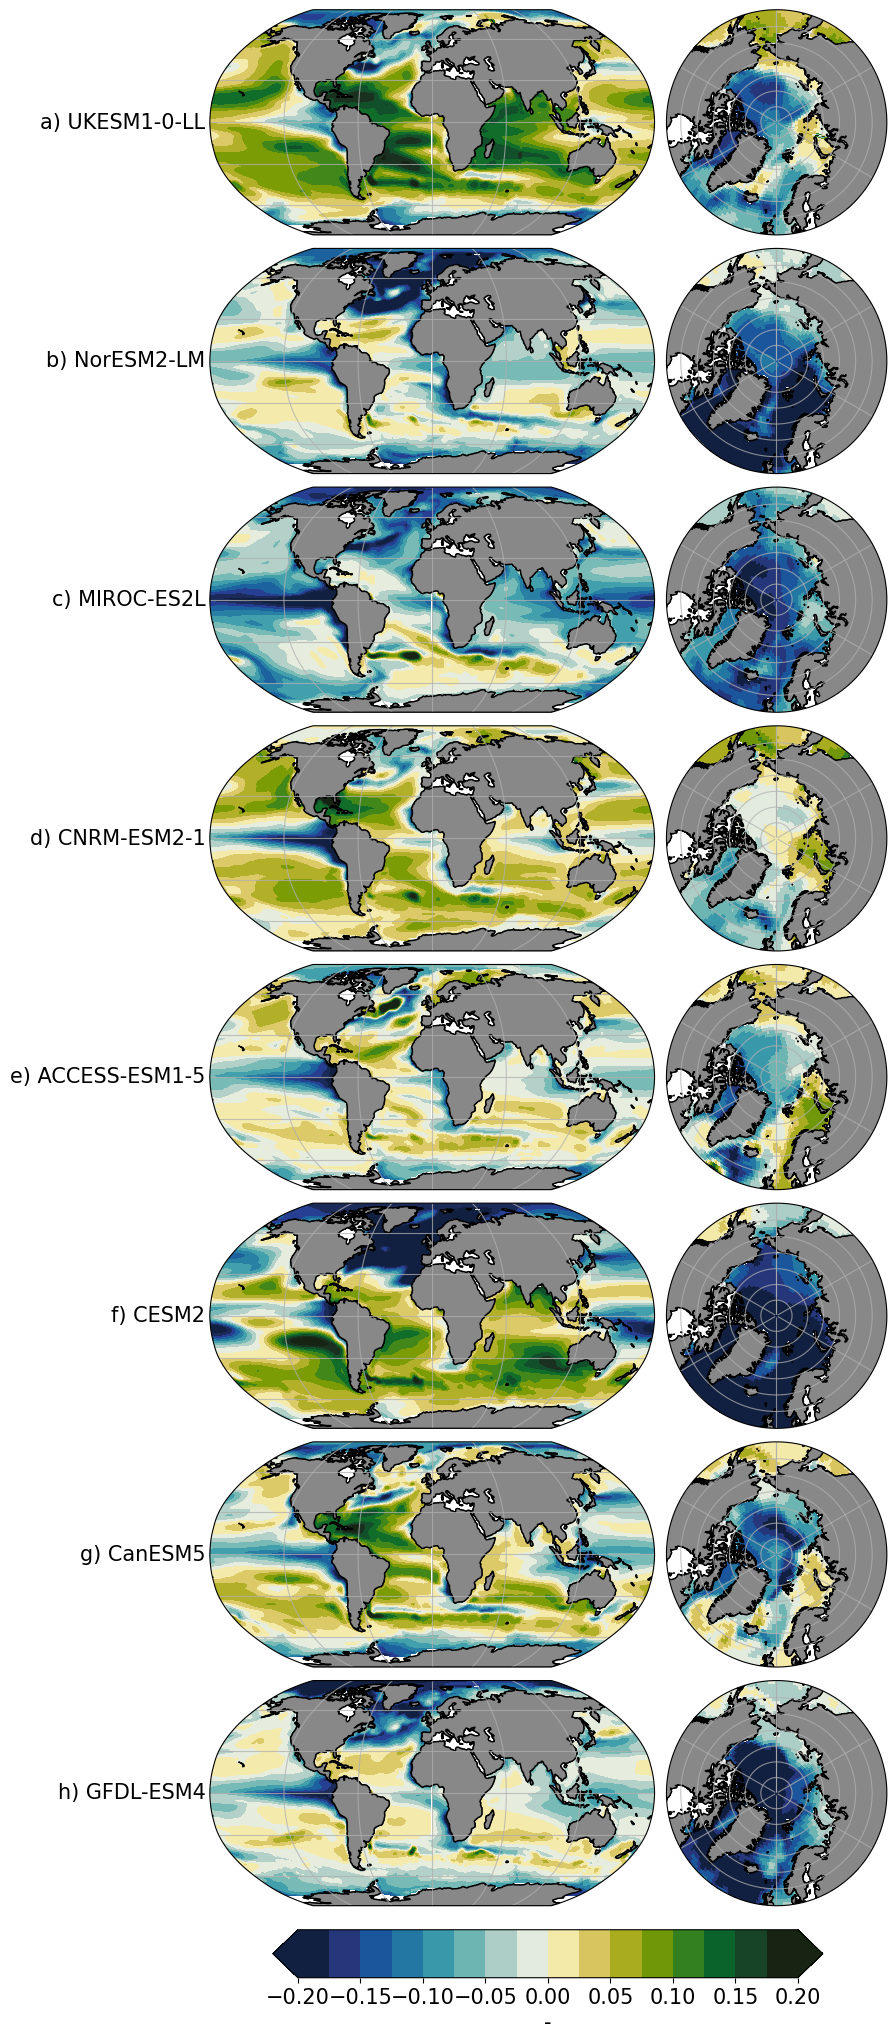

In [24]:
print('Plot the hysteresis areas for the individual models (Global and Arctic together).....')

fig = Plotter._plot_variable_for_individual_models_global_and_arctic(run_params,hyst_dict,da_name='signed_hysteresis_area',vmin=-.2,vmax=.2,cmap=plt.get_cmap('cmo.delta',16),unit=r'-',col=1)
if savefigs == True:
    fig.savefig(f'{plot_dir}/map_global_and_arctic_hysteresis_signed_individual_models_{variable_to_analyze}.png',dpi=300,transparent=True)

## Plot the Omega disequilibrium difference between the end of rampdown (260-280) and the start of rampup (0-20) to see where there are largest changes

In [25]:
print('First calculate the time slice differences in sCT for each model......')
time_slice_difference = xr.Dataset()
for key in run_params.keys(): # loop over runs
    rampdown_end = xr.open_dataset(run_paths[key])[temporal_resolution].isel(year=slice(260,280)).mean(dim='year')
    rampup_start = xr.open_dataset(run_paths[key])[temporal_resolution].isel(year=slice(0,20)).mean(dim='year')
    time_slice_difference[key] = rampdown_end - rampup_start

print('.... and compute the multi-model mean and agreement')
time_slice_difference_mmm, time_slice_difference_agreement = MMFuncs._calc_multimodel_mean_and_agreement(time_slice_difference, da_name=None, agreement_type = 'sign', agreement_thresh='at_least_80percent_agree')



First calculate the time slice differences in sCT for each model......
.... and compute the multi-model mean and agreement


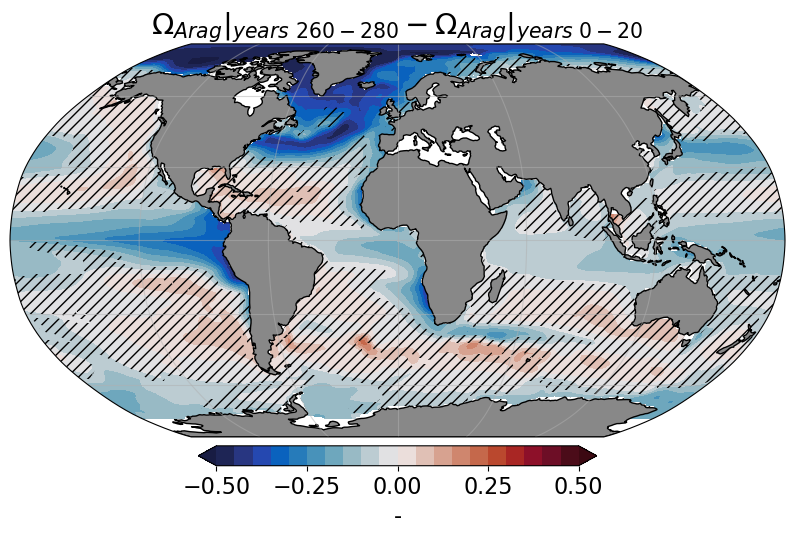

In [26]:
fig, ax = Plotter.plot_global_map(time_slice_difference_mmm,[],
                        -.5,.5,21,
                        plt.get_cmap('cmo.balance'),
                        [-.5,-.25,0,.25,.5],
                        'both',
                        r'-',
                        r'$\Omega_{Arag}|_{years\,\, 260-280} - \Omega_{Arag}|_{years\,\, 0-20}$',
                        agreement=time_slice_difference_agreement)
if savefigs == True:
    fig.savefig(f'{plot_dir}/map_global_time_slice_difference_omega.png',dpi=300,transparent=True)

In [27]:
central_arctic_diff = []
global_diff = []
for key in ['2','3','4','5','6','7','8','9']:
    central_arctic_diff.append(regional_time_series_2['central Arctic'][key].isel(year=280).values - regional_time_series_2['central Arctic'][key].isel(year=0).values)
    global_diff.append(regional_time_series_2['Global Ocean'][key].isel(year=280).values - regional_time_series_2['Global Ocean'][key].isel(year=0).values)
print('Central Arctic start end difference:')
print(f'{np.mean(central_arctic_diff)} +- {np.std(central_arctic_diff)}')
print('Global Ocean start end difference:')
print(f'{np.mean(global_diff)} +- {np.std(global_diff)}')


Central Arctic start end difference:
-0.3781707470406186 +- 0.10668777281054688
Global Ocean start end difference:
-0.046271606391444564 +- 0.04865588795820166
